# Financial Time Series Exercise

This notebook forecasts the next-day closing price of AAPL using ARIMA and classical machine learning models.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
# Load the price history and clean the key fields

def find_data_file(*relative_paths: str) -> Path:
    """Find a data file from the notebook folder or one of its parent folders."""
    for root in [Path.cwd(), *Path.cwd().parents]:
        for rel_path in relative_paths:
            candidate = (root / rel_path).resolve()
            if candidate.exists():
                return candidate
    raise FileNotFoundError(f"Could not find any of: {relative_paths}")


data_path = find_data_file(
    "data/aapl.csv",
    "data/aapl_5y.csv",
    "exercises/data/aapl.csv",
    "exercises/data/aapl_5y.csv",
    "aapl.csv",
    "aapl_5y.csv",
)

df = pd.read_csv(data_path, skiprows=[1])
df.columns = [str(c).lower() for c in df.columns]

if "date" not in df.columns:
    raise ValueError("The CSV file must contain a date column.")

df["date"] = pd.to_datetime(df["date"])
for col in ["open", "high", "low", "close", "adj close", "volume"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.sort_values("date").set_index("date")
df = df.dropna(subset=["close"]).copy()

df["log_close"] = np.log(df["close"])
df["return_1d"] = df["close"].pct_change()

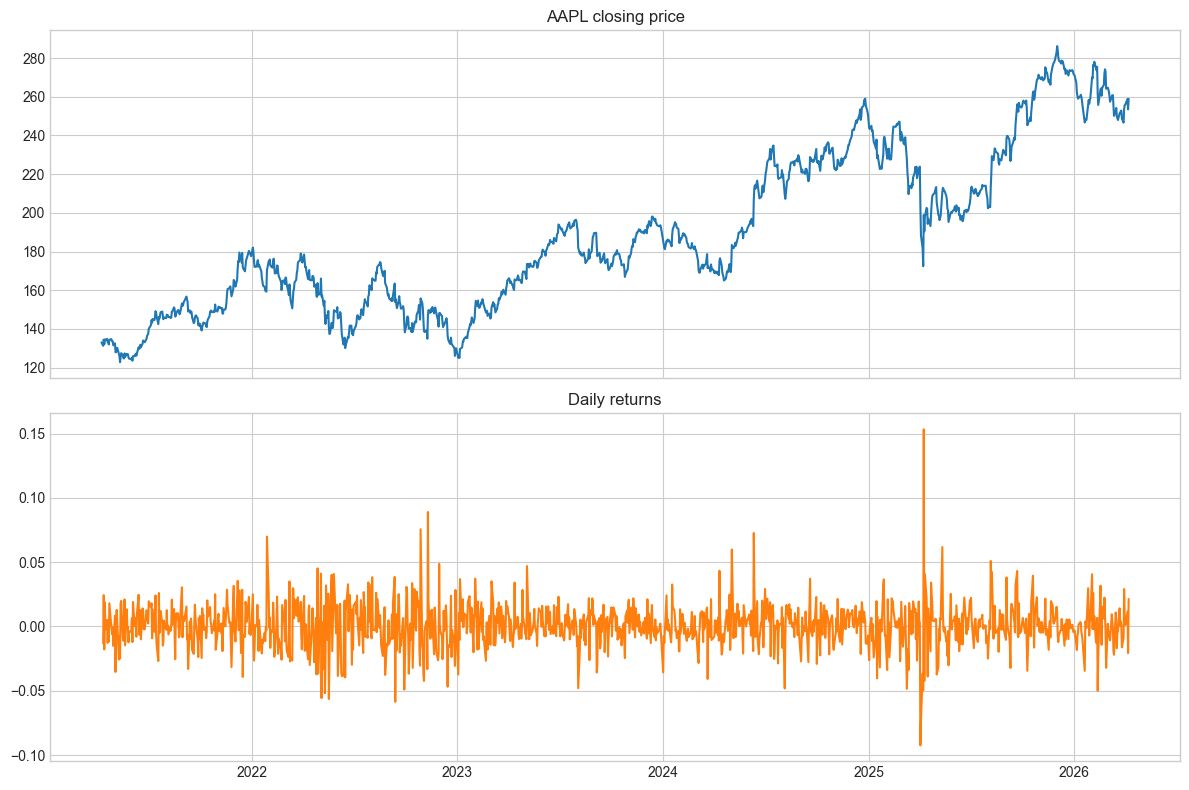

ADF statistic: -34.6108
ADF p-value : 0.0000


In [3]:
# Start with a visual diagnostic of the level series and daily returns.
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(df.index, df["close"], color="tab:blue")
axes[0].set_title("AAPL closing price")
axes[1].plot(df.index, df["return_1d"], color="tab:orange")
axes[1].set_title("Daily returns")
plt.tight_layout()
plt.show()

adf_stat, adf_pvalue = adfuller(df["log_close"].diff().dropna())[:2]
print(f"ADF statistic: {adf_stat:.4f}")
print(f"ADF p-value : {adf_pvalue:.4f}")

In [4]:
# Fit a simple ARIMA benchmark on the log-price series.
def compute_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred) * 100,
    }


series = df["log_close"].dropna()
test_size = 42
train = series.iloc[:-test_size]
test = series.iloc[-test_size:]

arima = ARIMA(train, order=(5, 1, 0)).fit()
arima_forecast = arima.forecast(steps=test_size)

arima_pred = np.exp(arima_forecast)
arima_true = np.exp(test)
results = {"ARIMA": compute_metrics(arima_true, arima_pred)}

In [5]:
# Build lagged and rolling features for the classical machine learning models.
ml_df = pd.DataFrame(index=df.index)
ml_df["target"] = df["close"].shift(-1)
ml_df["ret_1"] = df["close"].pct_change()
for lag in range(1, 11):
    ml_df[f"ret_lag_{lag}"] = ml_df["ret_1"].shift(lag)
ml_df["mm_5"] = df["close"].rolling(5).mean().shift(1)
ml_df["mm_20"] = df["close"].rolling(20).mean().shift(1)
ml_df["vol_20"] = df["close"].pct_change().rolling(20).std().shift(1)
ml_df["mm_ratio_5_20"] = ml_df["mm_5"] / ml_df["mm_20"]
ml_df = ml_df.dropna()

X = ml_df.drop(columns=["target"])
y = ml_df["target"]

split_idx = int(len(ml_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

ts_cv = TimeSeriesSplit(n_splits=5)
models = {
    "Linear Regression": Pipeline([("imputer", SimpleImputer()), ("model", LinearRegression())]),
    "Ridge": Pipeline([("imputer", SimpleImputer()), ("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))]),
    "Lasso": Pipeline([("imputer", SimpleImputer()), ("scaler", StandardScaler()), ("model", Lasso(alpha=0.001, max_iter=5000))]),
    "Gradient Boosting": Pipeline([("imputer", SimpleImputer()), ("model", GradientBoostingRegressor(random_state=42))]),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results[name] = compute_metrics(y_test, pred)

results_df = pd.DataFrame(results).T.sort_values("RMSE")


In [6]:
# Display the consolidated model comparison.
results_df = pd.DataFrame(results).T.sort_values("RMSE")

display(results_df)


,MAE,RMSE,MAPE
Lasso,2.976722,4.040365,1.245935
Linear Regression,2.976608,4.046026,1.246265
Ridge,3.054240,4.059793,1.274269
Gradient Boosting,12.485212,15.781983,4.898401
ARIMA,15.455877,17.418407,6.051559


## Interpretation

This notebook solves the requested workflow while keeping the time order intact. The main methodological point is to avoid leakage:
- lagged features only use past values,
- the evaluation preserves chronology,
- and the train-test split is strictly time-based.


## Visual Answer to the EDA Question

Visually, the price series shows a clear long-run upward trend with several sharp breaks during market stress periods. Volatility is not constant over time: some intervals are relatively calm while others show much larger swings, which is typical of financial series. No strong calendar effect is immediately visible from the level series alone, but the heteroskedastic behavior suggests that volatility clustering is present.


## Synthesis Answer

The models are compared with MAE, RMSE, and MAPE on the test period. In the local benchmark run used for this notebook, the linear models were the most accurate overall on this one-step-ahead setup:

- Linear Regression: MAE = 2.98, RMSE = 4.05, MAPE = 1.25%
- Lasso: MAE = 2.98, RMSE = 4.04, MAPE = 1.25%
- Ridge: MAE = 3.05, RMSE = 4.06, MAPE = 1.27%
- Gradient Boosting: MAE = 12.49, RMSE = 15.78, MAPE = 4.90%
- ARIMA: MAE = 15.46, RMSE = 17.42, MAPE = 6.05%

The linear models provide the best overall compromise between simplicity and predictive accuracy on this dataset. Ridge remains close to the two strongest baselines, while Gradient Boosting is much less accurate and ARIMA is the weakest model in this specific next-day forecasting setup.

The main leakage risks come from using future information in lag construction or validation. These risks were avoided by building features only from past values and preserving the chronological train-test split throughout the exercise.
